# Pet: inspect an image task, save an experiment, run three iterations

This is a **process demo**, not a paper artifact or an accuracy benchmark. You will classify 37 cat/dog breeds with a generated model. Low scores and failed Health checks are useful visible outcomes; no score threshold is required.

**Follow this sequence:** 1. locate your external project → 2. see images and split files → 3. edit and save experiment settings → 4. optionally create a new split → 5. review files and the exact command → 6. run your saved script → 7. plot its recorded scores.

Follow the [Pet setup guide](https://github.com/yuema137/siderius-exp/blob/main/tutorials/supplementary/pet/README.md) for installation, initialization and the notebook kernel; the [directory guide](https://github.com/yuema137/siderius-exp/blob/main/tutorials/README.md#source-project-data-and-run-directories) explains the shared path conventions.

### Download the images before running cells

From the installed exp checkout, download and extract the official dataset:

```bash
export PET_DATA="/absolute/path/data/OXFORD_IIIT_PET"
cd /absolute/path/siderius-exp
.venv/bin/python -m tasks.oxford_iiit_pet.tools.fetch_oxford_iiit_pet \
  --dest "$PET_DATA" --extract
```

The helper verifies both original archives. Initialize with `--images "$PET_DATA/images"`, the directory containing files such as `Abyssinian_100.jpg`, not the archive directory. This becomes `data_dir` in `experiments/pet-demo.json`. Keep the downloaded images for subsequent runs. The notebook checks declared filenames; launch also decodes search images. Resolve missing files before proceeding. `RUN_QUICK_DEMO=False` skips training, not the image preview.

```text
my-pet-project/
  project.json                         # source-checkout bindings
  tasks/pet/compositions/bounded_qualification.yaml
  tasks/pet/data/manifests/*.csv        # image membership and class labels
  tasks/pet/declared/                   # tensor, metric, Health declarations
  llm/agents.json                      # provider/model/planner, never API keys
  experiments/workflow.json            # fixed workflow and native flags
  experiments/pet-demo.json            # iterations, fractions, budgets, paths
  scripts/run-pet.sh                   # reads that saved experiment
  notebooks/pet_tutorial.ipynb          # this editable notebook
  data/images.json                    # initial image location, no copied JPEGs
  runs/pet_demo_001/                   # generated models and result records
  plots/                              # exported score chart and CSV
```

The **task package** defines what data mean, the model's input/output and what counts as a score/valid result. The **experiment** chooses how many iterations to try, data fractions and resource limits. The **workflow** connects the agent and execution stages. Changing a budget does not redefine the classification task.

**Recorded example:** the repository version retains images and a chart from a completed three-iteration run on an RTX 5090 (infra `e800fc1f`, exp executable `abe3cdd`). Formal accuracy was 0.1486, 0.2162 and 0.1892. All three Formal points passed Health; the first Trial scored 0 and failed collapse checks. The chart shows Formal attempts only, so it has no hollow points in this particular run. Failed measured Formal points are rendered hollow when present. Output paths are normalized for display. Initialization clears those example outputs from your copy, so a failed or interrupted first run cannot leave old example scores looking like your results. Your copy reads your own files and produces your own results.
**LLM configuration for this demo:** a new project saves `llm/agents.json` with OpenAI `gpt-6-luna` and `medium` reasoning for every workflow route, plus the built-in `native-timing-v1` planner. Inspect that file before running; it is independent of paper experiment routing. Iterations, training budgets and repair attempts remain separate experiment controls. This profile has offline checks, not yet a successful live Luna qualification. The pictures and scores already displayed here come from earlier recorded runs with their original models.

## Hardware before Run All

Training needs one supported NVIDIA GPU, the paired CUDA environment and working driver memory accounting. CPU machines can inspect data or plot existing results, but cannot run this training demo. AMD/ROCm remains experimental and currently lacks the accounting required by this route; Intel GPU training is unsupported. Select one device with `CUDA_VISIBLE_DEVICES` before starting Jupyter.

The shipped short demo sets a **8 GiB VRAM allowance**. The GPU must have greater physical capacity, and its current occupied memory plus the larger saved Trial/Formal allowance must fit within the device/deployment limit. This is a configured allowance, not a measured model minimum. Lowering it does not make every generated model fit.

Allow space for archives, extracted images and checkpoints. A small training subset does not remove the original dataset or extraction space. No universal training host-RAM minimum has been qualified. The hardware report shows host RAM and output-filesystem space as observations, not a guarantee of sufficient memory for this workload.

**Check without paying or training:** Project initialization creates this JSON. If you select a saved variant, replace the filename with the selected JSON printed by the notebook.

```bash
cd /absolute/path/siderius-exp
.venv/bin/python -m tutorials.shared.hardware \
  --experiment "$TUTORIAL_HOME/experiments/pet-demo.json"
```

This hardware-only command needs no API key and creates no run workspace; it queries the GPU and runs a tiny kernel. It does not replace task/data/configuration review. Fresh Run All launches repeat the GPU check automatically before provider calls. A pass does not reserve memory or prove that a future generated model fits; native measurement and monitoring still apply. Set `RUN_QUICK_DEMO=False` for a CPU/offline walkthrough. See the [hardware setup guide](https://github.com/yuema137/siderius-exp/blob/main/tutorials/shared/hardware/README.md) for limits and corrective steps.


In [1]:
import json
import os
import sys
from pathlib import Path

project_env = os.environ.get("TUTORIAL_HOME")
if not project_env:
    raise RuntimeError(
        "Export TUTORIAL_HOME to your initialized external project, then restart Jupyter from that terminal."
    )
PROJECT = Path(project_env).expanduser().resolve()
if not (PROJECT / "project.json").is_file():
    raise RuntimeError(
        "TUTORIAL_HOME must contain project.json; complete the README project initialization first."
    )
binding = json.loads((PROJECT / "project.json").read_text())
EXP_CHECKOUT = Path(binding["exp_checkout"])
if Path(sys.prefix).resolve() != (EXP_CHECKOUT / ".venv").resolve():
    raise RuntimeError(
        "Select the registered SIDERIUS Pet tutorial kernel from this project's exp checkout; see README setup."
    )
sys.dont_write_bytecode = True
os.chdir(EXP_CHECKOUT)
from IPython.display import Markdown, display

from tutorials.supplementary.pet.data import inspect_data, resplit_task
from tutorials.supplementary.pet.demo import plot_results, review, run_demo, show_images
from tutorials.supplementary.pet.project import save_variant
from tutorials.supplementary.pet.settings import PetExperiment

SELECTED_EXPERIMENT = "pet-demo"  # Or a saved variant name, e.g. "pet-more-001".
EXPERIMENT = PROJECT / "experiments" / f"{SELECTED_EXPERIMENT}.json"
SCRIPT = (
    PROJECT
    / "scripts"
    / (
        "run-pet.sh"
        if SELECTED_EXPERIMENT == "pet-demo"
        else f"run-{SELECTED_EXPERIMENT}.sh"
    )
)
settings = PetExperiment.model_validate_json(EXPERIMENT.read_text())
print(f"Selected: {EXPERIMENT}\nScript: {SCRIPT}\nImages: {settings.data_dir}")

Editing: /path/to/my-pet-project/experiments/pet-demo.json
Script: /path/to/my-pet-project/scripts/run-pet.sh
Images: /path/to/data/OXFORD_IIIT_PET/images


## 2. See the images and membership files

Your downloaded JPEGs stay in the `data_dir` recorded in your experiment. This notebook neither downloads nor uploads them. Each manifest row contains `image_id,class_index,official_class_id,scope`; `<image_id>.jpg` identifies one image. The task converts RGB images to float32 `[3,144,144]` in `[0,1]`; a batch is `[B,3,144,144]`, targets are integer class indices 0–36, and model outputs are `[B,37]` logits.

The initial small pool has 370 training and 74 validation images. **Validation scores are shown to the agent**. A separate 370-image final set remains outside search and is not evaluated in this demo.

train: 370 images; per-class counts: {0: 10, 1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10, 7: 10, 8: 10, 9: 10, 10: 10, 11: 10, 12: 10, 13: 10, 14: 10, 15: 10, 16: 10, 17: 10, 18: 10, 19: 10, 20: 10, 21: 10, 22: 10, 23: 10, 24: 10, 25: 10, 26: 10, 27: 10, 28: 10, 29: 10, 30: 10, 31: 10, 32: 10, 33: 10, 34: 10, 35: 10, 36: 10}; CSV: /path/to/my-pet-project/tasks/pet/data/manifests/gate2_train.csv
validation: 74 images; per-class counts: {0: 2, 1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 2, 7: 2, 8: 2, 9: 2, 10: 2, 11: 2, 12: 2, 13: 2, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2, 19: 2, 20: 2, 21: 2, 22: 2, 23: 2, 24: 2, 25: 2, 26: 2, 27: 2, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2, 34: 2, 35: 2, 36: 2}; CSV: /path/to/my-pet-project/tasks/pet/data/manifests/gate2_validation.csv
final: 370 images; per-class counts: {0: 10, 1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10, 7: 10, 8: 10, 9: 10, 10: 10, 11: 10, 12: 10, 13: 10, 14: 10, 15: 10, 16: 10, 17: 10, 18: 10, 19: 10, 20: 10, 21: 10, 22: 10, 23: 10, 24: 10, 25: 10, 26

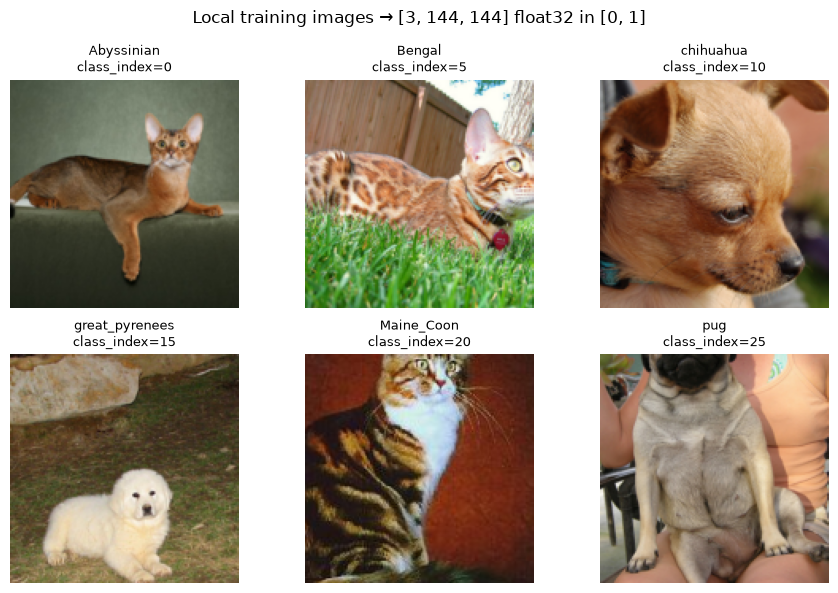

In [2]:
reports = inspect_data(settings.composition, settings.data_dir)
for role, report in reports.items():
    print(
        f"{role}: {report.count} images; per-class counts: {report.per_class}; CSV: {report.manifest}"
    )
print(reports["train"].manifest.read_text().splitlines()[:4])
import matplotlib.pyplot as plt

image_figure = show_images(EXPERIMENT)
display(image_figure)
plt.close(image_figure)

## 3. Inspect saved settings, or save a named variant

The initialized experiment contains the demo defaults: three iterations, two rounds, 32 epochs, Trial fractions 0.5, Formal fractions 1.0, 2/5-minute ceilings and 8 GiB. Run All reads the selected JSON without replacing your edits. An **iteration** proposes/implements a model; within it, two tuner rounds provide Trial and Formal attempts. Epochs and time are ceilings, so a run may stop earlier. Trial uses a fraction of the declared image pool; Formal evaluates the larger scope. A fractional scope is not a stratified sample and can omit breeds. Use full fractions or create a deliberate split if class coverage matters.

`train_portion=1.0` disables additional per-epoch subsampling. Pet does not support a smaller value. The generated training configuration still controls batching: with `drop_last=True`, an incomplete last batch is omitted. Inspect the saved training config and loader counts when exact examples-per-epoch matter. `vram_gib` sets both attempt budgets unless a Trial/Formal override is set. Time limits apply to individual attempts; they are **not** an API-dollar cap or a whole-demo timeout.

LLM choices live in `llm/agents.json`; this new demo explicitly uses `native-timing-v1`. Data Analysis, literature review and human advice are disabled. No advice file is active.

For your first run, leave `SAVE_VARIANT=False`. You can edit the selected JSON in Jupyter's `experiments/` folder and rerun this cell to read it back; the notebook does not reset it.

For another run, set `SAVE_VARIANT=True`, choose a new `VARIANT_NAME`, and edit `CHANGES`. The example changes only iterations from 3 to 4. The helper reloads your selected JSON, applies those changes, and creates **both** `experiments/pet-more-001.json` and `scripts/run-pet-more-001.sh`, with a new `runs/pet-more-001/` output. It selects those files for the remaining cells. Original JSON/script/results stay intact; existing variant names are refused. Saving runs no training.

After saving once, set `SAVE_VARIANT=False` and set `SELECTED_EXPERIMENT="pet-more-001"` in the first cell for later Run All passes. If you want different settings, choose another variant name.

The demo uses a 32-epoch ceiling because its tiny validation pool can produce only one timing observation per epoch. The first 8-epoch qualification stopped before validation timing stabilized. A larger ceiling permits more observations; it does not waive calibration, guarantee success on another GPU, or require training to use the entire time budget.

In [3]:
SAVE_VARIANT = False
VARIANT_NAME = "pet-more-001"
CHANGES = {"iterations": 4}
if SAVE_VARIANT:
    EXPERIMENT, SCRIPT = save_variant(
        PROJECT, EXPERIMENT, name=VARIANT_NAME, changes=CHANGES
    )
settings = PetExperiment.model_validate_json(EXPERIMENT.read_text())
print(f"Selected saved JSON: {EXPERIMENT}\nMatching script: {SCRIPT}")
print(EXPERIMENT.read_text())

Saved: /path/to/my-pet-project/experiments/pet-demo.json
{
  "version": "pet-tutorial-v1",
  "infra_checkout": "/path/to/SIDERIUS",
  "data_dir": "/path/to/data/OXFORD_IIIT_PET/images",
  "workspace": "/path/to/my-pet-project/runs/pet_demo_001",
  "composition": "/path/to/my-pet-project/tasks/pet/compositions/bounded_qualification.yaml",
  "llm_config": "/path/to/my-pet-project/llm/agents.json",
  "workflow": "/path/to/my-pet-project/experiments/workflow.json",
  "run_name": "pet_demo_001",
  "gpu": "RTX 5090",
  "iterations": 3,
  "rounds": 2,
  "epochs": 32,
  "trial_train_fraction": 0.5,
  "trial_val_fraction": 0.5,
  "formal_train_fraction": 1.0,
  "formal_val_fraction": 1.0,
  "trial_minutes": 2.0,
  "formal_minutes": 5.0,
  "vram_gib": 8.0,
  "trial_vram_gib": null,
  "formal_vram_gib": null,
  "train_portion": 1.0,
  "advice_file": null
}



## 4. Optional: save a different train/validation split

This example takes only the **444 existing training+validation images**, shuffles within each breed with seed 2026 and holds out three images per breed: 333 training, 111 validation. It writes a new task directory, CSVs, composition and profile; the old task and final manifest stay unchanged. Validation still feeds the agent, so it is not an unseen final test.

Leave `MAKE_NEW_SPLIT=False` on your first run. Set it to True before your first launch to try the example. To repeat resplitting, choose another destination name; existing task directories are refused. This also saves a new experiment/script named `pet-split-2026`; it does not modify your selected original JSON. After saving, set `MAKE_NEW_SPLIT=False` and `SELECTED_EXPERIMENT="pet-split-2026"` for later Run All passes. Review the new file pair before launching.

In [4]:
MAKE_NEW_SPLIT = False
SPLIT_NAME = "pet-split-2026"
if MAKE_NEW_SPLIT:
    new_composition = resplit_task(
        settings.composition,
        PROJECT / "tasks" / SPLIT_NAME,
        validation_per_class=3,
        seed=2026,
    )
    EXPERIMENT, SCRIPT = save_variant(
        PROJECT,
        EXPERIMENT,
        name=SPLIT_NAME,
        changes={"composition": new_composition},
    )
    settings = PetExperiment.model_validate_json(EXPERIMENT.read_text())
    print(
        f"New task: {new_composition}\nNew experiment: {EXPERIMENT}\nNew script: {SCRIPT}"
    )

## 5. Before running: inspect these saved files and the actual command

Check the displayed data counts, task composition, model routing, all experiment values and output directory. Keys must be exported in the **terminal that starts Jupyter**; restarting only the kernel does not inherit keys added to another terminal. The preview checks installed revisions/strategy and image membership but makes no API call or CUDA allocation. Missing keys are reported by name; real launch refuses them and checks CUDA and image decoding before effects.

For an existing completed run, skip the native fresh-workspace preview; step 6 verifies unchanged inputs and reuses its results.
For an offline file-editing walkthrough without native environment/source checks, set `RUN_NATIVE_PREVIEW=False` below and `RUN_QUICK_DEMO=False` in step 6. The saved-file review still checks the script binding and local image membership. A fresh real launch always performs its native checks.


In [5]:
settings = PetExperiment.model_validate_json(EXPERIMENT.read_text())
display(Markdown(review(EXPERIMENT, SCRIPT)))
import subprocess

RUN_NATIVE_PREVIEW = True
if RUN_NATIVE_PREVIEW and not settings.workspace.exists():
    preview = subprocess.run(
        ["bash", str(SCRIPT)], text=True, capture_output=True, check=False
    )
    print(preview.stdout)
    if preview.returncode:
        raise RuntimeError(preview.stderr)
else:
    print(
        "Native preview skipped: disabled or workspace already exists. No training was started."
    )

Saved input: `/path/to/my-pet-project/experiments/pet-demo.json`

| Setting | Effective value |
|---|---|
| `version` | `pet-tutorial-v1` |
| `infra_checkout` | `/path/to/SIDERIUS` |
| `data_dir` | `/path/to/data/OXFORD_IIIT_PET/images` |
| `workspace` | `/path/to/my-pet-project/runs/pet_demo_001` |
| `composition` | `/path/to/my-pet-project/tasks/pet/compositions/bounded_qualification.yaml` |
| `llm_config` | `/path/to/my-pet-project/llm/agents.json` |
| `workflow` | `/path/to/my-pet-project/experiments/workflow.json` |
| `run_name` | `pet_demo_001` |
| `gpu` | `RTX 5090` |
| `iterations` | `3` |
| `rounds` | `2` |
| `epochs` | `32` |
| `trial_train_fraction` | `0.5` |
| `trial_val_fraction` | `0.5` |
| `formal_train_fraction` | `1.0` |
| `formal_val_fraction` | `1.0` |
| `trial_minutes` | `2.0` |
| `formal_minutes` | `5.0` |
| `vram_gib` | `8.0` |
| `trial_vram_gib` | `None` |
| `formal_vram_gib` | `None` |
| `train_portion` | `1.0` |
| `advice_file` | `None` |

train: 370 images (37 breeds), validation: 74 images (37 breeds), final: 370 images (37 breeds). Final is separate and is **not** scored during search.

Data Analysis, literature review and human advice are **disabled**. This fixed workflow does not use a workflow sandbox. Generated models run through native execution checks.

Inspect the task composition and its referenced CSVs, then `llm/agents.json` (model/provider/strategy, never API keys), `experiments/workflow.json` (fixed workflow), and the experiment above (run choices). The native preview below prints all additional workflow flags.

Preview (no API/GPU):
```bash
bash '/path/to/my-pet-project/scripts/run-pet.sh'
```

Launch the saved experiment (API/GPU effects):
```bash
bash '/path/to/my-pet-project/scripts/run-pet.sh' --launch
```

Outputs: `/path/to/my-pet-project/runs/pet_demo_001`. When this notebook launches the script, its console log and completion receipt sit beside this directory. A direct terminal launch prints to your terminal and saves a `.tutorial.json` launch receipt. Plot exports go to your project's `plots/` directory.


Workspace exists: step 6 will only reuse a matching completion receipt; it will not resume or overwrite.


## 6. Run the saved script

**This cell makes paid LLM calls and uses your NVIDIA GPU.** It delegates to the exact selected script and JSON reviewed above (`scripts/run-pet.sh --launch` for the initial experiment). Models can generate invalid code or fail Health; the demo does not guarantee a score or accuracy. Use provider-side spending controls for your own account.

`RUN_QUICK_DEMO=True` lets Run All execute the workflow. Set it to False for an offline walkthrough. A recorded run with unchanged task/config/script inputs is reused without new calls. Changed or interrupted runs require a new output workspace. Interrupt stops the native process group. The notebook timeout is 60 minutes; it does not enforce API-dollar or GPU-usage limits.

In [6]:
RUN_QUICK_DEMO = True
if RUN_QUICK_DEMO:
    completion = run_demo(EXPERIMENT, SCRIPT, timeout_seconds=3600)
    print(json.dumps(completion, indent=2))
else:
    print("Offline walkthrough: no API calls or training.")

Reusing recorded result without API/GPU work: /path/to/my-pet-project/runs/pet_demo_001
{
  "input_sha256": "93a023929b1817c47bc12d473900b268c0fadb5bf3bf896a30c063d2f797a93b",
  "exit_code": 0,
  "elapsed_seconds": 1153.609521470964,
  "workspace": "/path/to/my-pet-project/runs/pet_demo_001",
  "log": "/path/to/my-pet-project/runs/pet_demo_001.console.log"
}


## 7. Plot your recorded scores

This reads your workspace, not a bundled example. It writes PNG, SVG and CSV under `plots/`. Filled points passed recorded Health checks; hollow points have measured scores but failed checks. Attempts with no score remain unscored. The solid line tracks the best recorded score, including failed points; hollow markers distinguish those results from Health-passing observations. Three requested iterations may produce fewer points if execution fails; inspect the log instead of interpreting missing points as zero accuracy.

Set `PLOT_EXPERIMENT` below to another saved experiment JSON and choose `PLOT_OUTPUT`, then execute **only this plotting cell**. It works independently of `RUN_QUICK_DEMO`, including when that flag is False or a prior launch cell failed. Restore the original saved JSON if it is missing; plotting needs its workspace setting. There is no separate final-set evaluation in this demo.

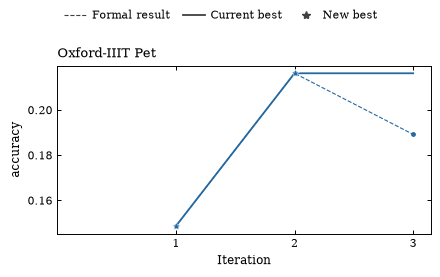

PNG/SVG/CSV: /path/to/my-pet-project/plots/pet_demo_001


In [7]:
PLOT_EXPERIMENT = EXPERIMENT  # Or PROJECT / "experiments/pet-demo.json".
plot_settings = PetExperiment.model_validate_json(PLOT_EXPERIMENT.read_text())
PLOT_OUTPUT = PROJECT / "plots" / plot_settings.run_name
if plot_settings.workspace.is_dir():
    score_figure = plot_results(PLOT_EXPERIMENT, PLOT_OUTPUT)
    display(score_figure)
    plt.close(score_figure)
    print(f"PNG/SVG/CSV: {PLOT_OUTPUT}")
else:
    print(
        "No run workspace yet. Run the saved script or select a completed PLOT_EXPERIMENT."
    )